In [106]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib.abstract as ta
import scipy as sp


In [204]:
# Apple Futures data using yfinance
ticker = 'AAPL'
data = yf.download(ticker, start="2025-01-01", interval="1h")

# Check the data
display(data.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2025-01-02 14:30:00+00:00,245.739899,249.100006,244.800003,248.929993,13501229
2025-01-02 15:30:00+00:00,244.895004,245.880005,244.160095,245.630005,6830782
2025-01-02 16:30:00+00:00,243.428604,245.250000,243.320007,244.909897,4384552
2025-01-02 17:30:00+00:00,242.686203,243.410004,242.309998,243.410004,6464462
2025-01-02 18:30:00+00:00,242.488403,242.839996,241.820099,242.669998,5547977


In [205]:
data.columns = ['Close','High','Low','Open','Volume']

In [206]:
data_copy = data.copy()

In [207]:
data_copy['Previous High'] = data_copy['High'].shift(1)
data_copy['Previous Low'] = data_copy['Low'].shift(1)

In [208]:
data_copy.head()

,Close,High,Low,Open,Volume,Previous High,Previous Low
Datetime,,,,,,,
2025-01-02 14:30:00+00:00,245.739899,249.100006,244.800003,248.929993,13501229,NaN,NaN
2025-01-02 15:30:00+00:00,244.895004,245.880005,244.160095,245.630005,6830782,249.100006,244.800003
2025-01-02 16:30:00+00:00,243.428604,245.250000,243.320007,244.909897,4384552,245.880005,244.160095
2025-01-02 17:30:00+00:00,242.686203,243.410004,242.309998,243.410004,6464462,245.250000,243.320007
2025-01-02 18:30:00+00:00,242.488403,242.839996,241.820099,242.669998,5547977,243.410004,242.309998


In [209]:
def add_gaps_columns(data:pd.DataFrame)->pd.DataFrame:
    data['Gap Up'] = (data['Low'] > data['Previous High'])
    data['Gap Down'] = (data['High'] < data['Previous Low'])
    return data

In [210]:
data_copy = add_gaps_columns(data_copy)
data_copy.head()

,Close,High,Low,Open,Volume,Previous High,Previous Low,Gap Up,Gap Down
Datetime,,,,,,,,,
2025-01-02 14:30:00+00:00,245.739899,249.100006,244.800003,248.929993,13501229,NaN,NaN,False,False
2025-01-02 15:30:00+00:00,244.895004,245.880005,244.160095,245.630005,6830782,249.100006,244.800003,False,False
2025-01-02 16:30:00+00:00,243.428604,245.250000,243.320007,244.909897,4384552,245.880005,244.160095,False,False
2025-01-02 17:30:00+00:00,242.686203,243.410004,242.309998,243.410004,6464462,245.250000,243.320007,False,False
2025-01-02 18:30:00+00:00,242.488403,242.839996,241.820099,242.669998,5547977,243.410004,242.309998,False,False


In [213]:
def add_difference_of_gaps(data:pd.DataFrame) -> pd.DataFrame:
    data['Gap_Size'] = 0.0
    #get the difference between the row where gap is up
    mask_up = data['Gap Up'] == True 
    data.loc[mask_up, 'Gap_Size'] = data['Low'] - data['Previous High']
    #get the difference between the row where gap is down
    mask_down = data['Gap Down'] == True
    data.loc[mask_down, 'Gap_Size'] = data['Previous Low'] - data['High']
    return data

In [214]:
data_copy = add_difference_of_gaps(data_copy)
data_copy.head()

,Close,High,Low,Open,Volume,Previous High,Previous Low,Gap Up,Gap Down,Gap_Size
Datetime,,,,,,,,,,
2025-01-02 14:30:00+00:00,245.739899,249.100006,244.800003,248.929993,13501229,NaN,NaN,False,False,0.0
2025-01-02 15:30:00+00:00,244.895004,245.880005,244.160095,245.630005,6830782,249.100006,244.800003,False,False,0.0
2025-01-02 16:30:00+00:00,243.428604,245.250000,243.320007,244.909897,4384552,245.880005,244.160095,False,False,0.0
2025-01-02 17:30:00+00:00,242.686203,243.410004,242.309998,243.410004,6464462,245.250000,243.320007,False,False,0.0
2025-01-02 18:30:00+00:00,242.488403,242.839996,241.820099,242.669998,5547977,243.410004,242.309998,False,False,0.0


In [ ]:
def set_mean_volume(data:pd.DataFrame)->pd.DataFrame:
    # Yeo-Johnson transformatörünü tanımla
    pt = PowerTransformer(method='yeo-johnson', standardize=True)

    # Veriyi fit et ve dönüştür
    difference_obv_transformed = pt.fit_transform(data_copy['Volume'].values.reshape(-1, 1)).flatten()

In [ ]:
def get_common_gaps(data:pd.DataFrame)->pd.DataFrame:
    gap_data = data_copy[data_copy['Gap_Size'] > 0]['Gap_Size']

In [179]:
# 1. Gap Boyutlarını Hesapla (Sadece Gap olan yerler için)
data_copy['Gap_Size'] = 0.0

# Gap Up olan yerlerde farkı hesapla
mask_up = data_copy['Gap Up'] == True
data_copy.loc[mask_up, 'Gap_Size'] = data_copy['Low'] - data_copy['Previous High']

# Gap Down olan yerlerde farkı hesapla (Pozitif değer elde etmek için mutlak değer veya ters çıkarım)
mask_down = data_copy['Gap Down'] == True
data_copy.loc[mask_down, 'Gap_Size'] = data_copy['Previous Low'] - data_copy['High']

# 2. Sadece Gap olan satırları filtrele (Sıfırdan büyük olanlar)
gap_data = data_copy[data_copy['Gap_Size'] > 0]['Gap_Size']

In [180]:
# 3. İstatistikleri Hesapla
gap_mean = gap_data.mean()
gap_std = gap_data.std()

lower_bound = gap_mean - gap_std
upper_bound = gap_mean + gap_std

# 4. Anomali Tespiti
def detect_anomaly(row):
    if row['Gap Up'] or row['Gap Down']:
        size = row['Gap_Size']
        if lower_bound <= size <= upper_bound:
            return 'Normal Gap'
        else:
            return 'Anomaly Gap'
    return 'No Gap'

data_copy['Gap_Type'] = data_copy.apply(detect_anomaly, axis=1)

print(f"Gap Ortalaması: {gap_mean:.2f}")
print(f"Standart Sapma: {gap_std:.2f}")
print(f"Normal Aralık: {lower_bound:.2f} ile {upper_bound:.2f}")

Gap Ortalaması: 1.77
Standart Sapma: 2.32
Normal Aralık: -0.55 ile 4.10


In [182]:
data_copy['Gap_Type'].value_counts()

Gap_Type
No Gap         1906
Normal Gap       61
Anomaly Gap       7
Name: count, dtype: int64

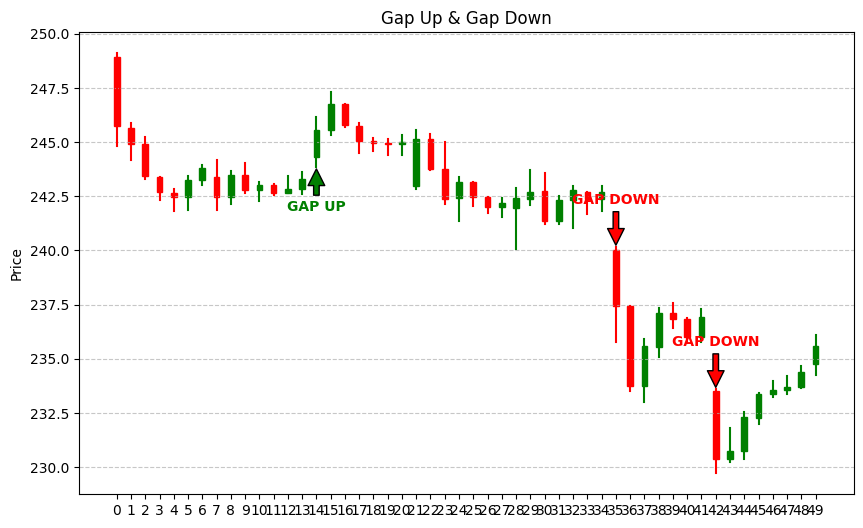

In [116]:
# 2. Grafik Oluşturma
data_plot = data_copy.iloc[:50,:]
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(data_plot)):
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # Mumun fitili (Yüksek - Düşük)
    ax.plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color)
    
    # Mumun gövdesi (Açılış - Kapanış)
    # Mum genişliğini ayarlamak için mdate veya sayısal indeks kullanılabilir
    height = data_plot.iloc[i]['Close'] - data_plot.iloc[i]['Open']
    rect = plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color, alpha=0.8)
    # Tarih ekseni yerine indeks üzerinden çizim yapıp sonra etiketleri düzelteceğiz
    ax.add_patch(plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color))

# 3. Gap İşaretlerini Ekleme
for i in range(len(data_plot)):
    if data_plot['Gap Up'].iloc[i]:
        ax.annotate('GAP UP', xy=(i, data_plot['Low'].iloc[i]), xytext=(i, data_plot['Low'].iloc[i]-2),
                    arrowprops=dict(facecolor='green', shrink=0.05),
                    ha='center', color='green', fontweight='bold')
    
    if data_plot['Gap Down'].iloc[i]:
        ax.annotate('GAP DOWN', xy=(i, data_plot['High'].iloc[i]), xytext=(i, data_plot['High'].iloc[i]+2),
                    arrowprops=dict(facecolor='red', shrink=0.05),
                    ha='center', color='red', fontweight='bold')

# 4. Estetik Ayarlar
ax.set_xticks(range(len(data_plot)))
#ax.set_xticklabels(data_copy.index)
ax.set_title('Gap Up & Gap Down')
ax.set_ylabel('Price')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Common gap

In [117]:
ma_vlolume = ta.SMA(data_copy['Volume'], timeperiod=30)
ma_vlolume

array([             nan,              nan,              nan, ...,
       6648362.33333333, 7782070.46666667, 8932131.1       ],
      shape=(1974,))

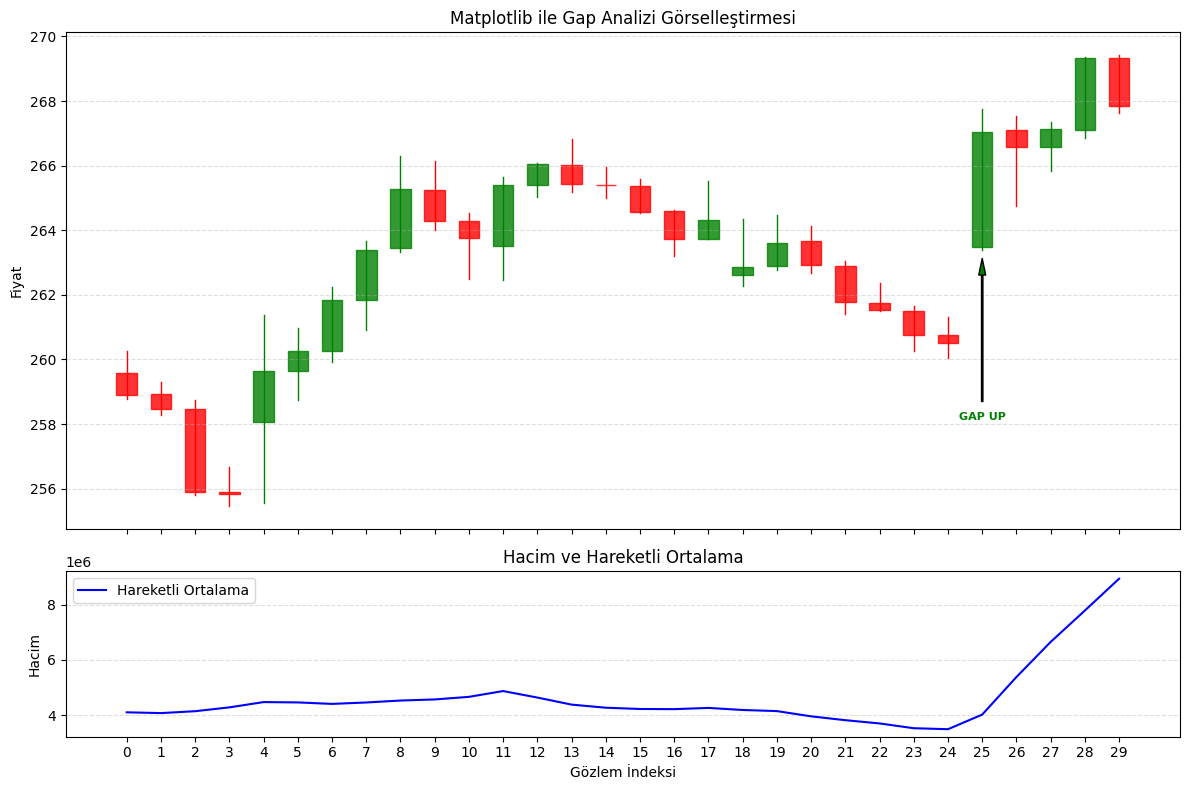

In [118]:
# 2. Grafik Oluşturma
data_plot = data_copy.iloc[-30:,:].copy()
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

for i in range(len(data_plot)):
    # Renk belirleme: Kapanış >= Açılış ise yeşil, değilse kırmızı
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # 1. Mumun fitili (Yüksek - Düşük)
    ax[0].plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color, linewidth=1)
    
    # 2. Mumun gövdesi (Açılış - Kapanış)
    open_price = data_plot.iloc[i]['Open']
    close_price = data_plot.iloc[i]['Close']
    height = close_price - open_price
    
    # Rectangle nesnesini doğrudan ilgili aksa (ax[0]) ekliyoruz
    rect = plt.Rectangle((i - 0.3, open_price), 0.6, height, color=color, alpha=0.8)
    ax[0].add_patch(rect)

# 3. Gap İşaretlerini Ekleme
for i in range(len(data_plot)):
    if data_plot['Gap Up'].iloc[i]:
        ax[0].annotate('GAP UP', xy=(i, data_plot['Low'].iloc[i]), 
                    xytext=(i, data_plot['Low'].iloc[i] * 0.98), # Fiyata göre dinamik ofset
                    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='green', fontweight='bold', fontsize=8)
    
    if data_plot['Gap Down'].iloc[i]:
        ax[0].annotate('GAP DOWN', xy=(i, data_plot['High'].iloc[i]), 
                    xytext=(i, data_plot['High'].iloc[i] * 1.02),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='red', fontweight='bold', fontsize=8)

# Üst Grafik Ayarları
ax[0].set_ylabel('Fiyat')
ax[0].set_title('Matplotlib ile Gap Analizi Görselleştirmesi')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)

# 4. Alt Grafik (Hacim/Line Graph)
# Not: ma_vlolume listesinin de ilk 30 verisini almayı unutmayın
ax[1].plot(range(len(data_plot)), ma_vlolume[-30:], label='Hareketli Ortalama', color='blue', linewidth=1.5)
ax[1].set_title('Hacim ve Hareketli Ortalama')
ax[1].set_ylabel('Hacim')
ax[1].set_xlabel('Gözlem İndeksi')
ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].legend()

# 5. Estetik ve Eksen Ayarları
plt.xticks(range(len(data_plot)))
plt.tight_layout()
plt.show()

In [154]:
obv = ta.OBV(data_copy['Open'], data_copy['Volume'])

In [155]:
#difference_obv = np.diff(obv)
obv_mean = data_copy['Volume'].mean()
obv_std = data_copy['Volume'].std()
upper_bound_obv = obv_mean + 2 * obv_std
lower_bound_obv = obv_mean - 2 * obv_std

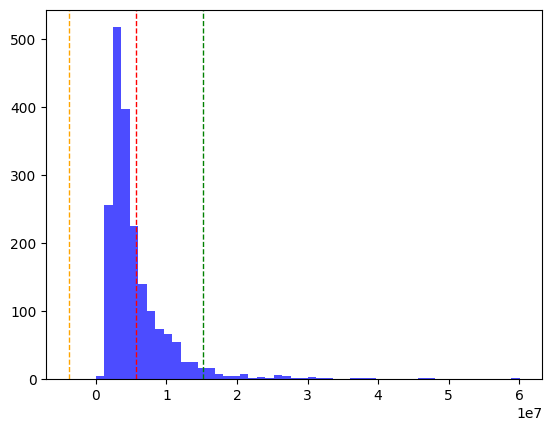

In [156]:
plt.hist(data_copy['Volume'], bins=50, color='blue', alpha=0.7)
plt.axvline(obv_mean, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(upper_bound_obv, color='green', linestyle='dashed', linewidth=1, label='Upper Bound (Mean + 1 Std)')
plt.axvline(lower_bound_obv, color='orange', linestyle='dashed', linewidth=1, label='Lower Bound (Mean - 1 Std)')

In [157]:
from sklearn.preprocessing import PowerTransformer

In [158]:
# Yeo-Johnson transformatörünü tanımla
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Veriyi fit et ve dönüştür
difference_obv_transformed = pt.fit_transform(data_copy['Volume'].values.reshape(-1, 1)).flatten()

In [169]:
transformed_mean = difference_obv_transformed.mean()
transformed_std = difference_obv_transformed.std()
upper_bound_transformed = transformed_mean + 1 * transformed_std
lower_bound_transformed = transformed_mean - 1 * transformed_std    

In [170]:
upper_bound_transformed, lower_bound_transformed

(np.float64(0.999999999999998), np.float64(-1.000000000000002))

In [171]:
id(upper_bound_transformed), id(lower_bound_transformed)

(281470853983184, 281470852727056)

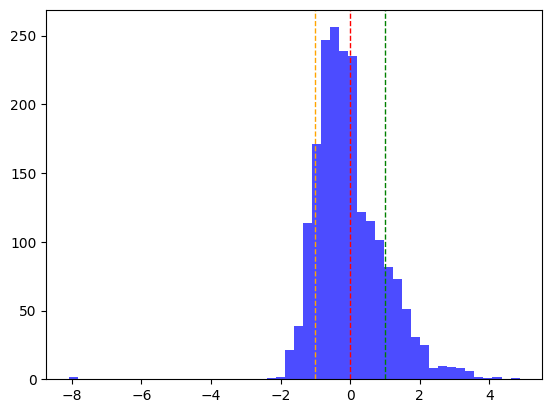

In [172]:
plt.hist(difference_obv_transformed, bins=50, color='blue', alpha=0.7)
plt.axvline(transformed_mean, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(upper_bound_transformed, color='green', linestyle='dashed', linewidth=1, label='Upper Bound (Mean + 1 Std)')
plt.axvline(lower_bound_transformed, color='orange', linestyle='dashed', linewidth=1, label='Lower Bound (Mean - 1 Std)')

In [173]:
data['Common Gaps'] = False

In [174]:
volume_anomaly = (difference_obv_transformed <= upper_bound_transformed) | (difference_obv_transformed >= lower_bound_transformed)

gap_exists = data_copy['Gap Up'] | data_copy['Gap Down']

data_copy.loc[data_copy.index, 'Common Gaps'] = volume_anomaly & gap_exists

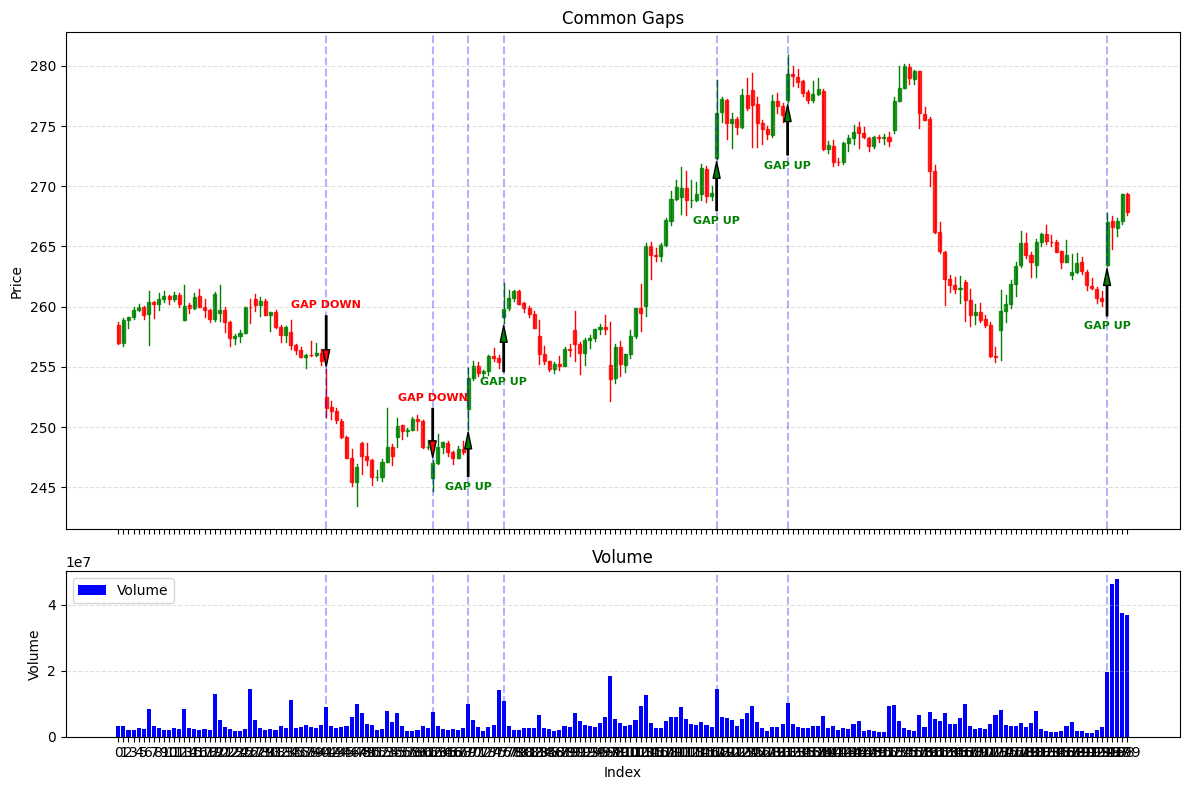

In [178]:
# 2. Grafik Oluşturma
data_plot = data_copy.iloc[-200:,:].copy()
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

for i in range(len(data_plot)):
    # Renk belirleme: Kapanış >= Açılış ise yeşil, değilse kırmızı
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # 1. Mumun fitili (Yüksek - Düşük)
    ax[0].plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color, linewidth=1)
    
    # 2. Mumun gövdesi (Açılış - Kapanış)
    open_price = data_plot.iloc[i]['Open']
    close_price = data_plot.iloc[i]['Close']
    height = close_price - open_price
    
    # Rectangle nesnesini doğrudan ilgili aksa (ax[0]) ekliyoruz
    rect = plt.Rectangle((i - 0.3, open_price), 0.6, height, color=color, alpha=0.8)
    ax[0].add_patch(rect)

    current_vol = difference_obv_transformed[i]
    if data_plot['Common Gaps'].iloc[i]:
        # Her iki grafiğe de dikey çizgi ekle
        for a in ax:
            a.axvline(x=i, color='blue', linestyle='--', alpha=0.3, linewidth=1.5)

# 3. Gap İşaretlerini Ekleme
for i in range(len(data_plot)):
    if data_plot['Gap Up'].iloc[i]:
        ax[0].annotate('GAP UP', xy=(i, data_plot['Low'].iloc[i]), 
                    xytext=(i, data_plot['Low'].iloc[i] * 0.98), # Fiyata göre dinamik ofset
                    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='green', fontweight='bold', fontsize=8)
    
    if data_plot['Gap Down'].iloc[i]:
        ax[0].annotate('GAP DOWN', xy=(i, data_plot['High'].iloc[i]), 
                    xytext=(i, data_plot['High'].iloc[i] * 1.02),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='red', fontweight='bold', fontsize=8)

# Üst Grafik Ayarları
ax[0].set_ylabel('Price')
ax[0].set_title('Common Gaps')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)

# 4. Alt Grafik (Hacim/Line Graph)
# Not: ma_vlolume listesinin de ilk 30 verisini almayı unutmayın
ax[1].bar(range(len(data_plot)), data_copy['Volume'].iloc[-len(data_plot):], label='Volume', color='blue', linewidth=1.5)
ax[1].set_title('Volume')
ax[1].set_ylabel('Volume')
ax[1].set_xlabel('Index')
ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].legend()

# 5. Estetik ve Eksen Ayarları
plt.xticks(range(len(data_plot)))
plt.tight_layout()
plt.show()

## MA

In [82]:
ma_vlolume = ta.SMA(data_copy['Volume'].shift(1), timeperiod=30)
short_ma_volume = ta.SMA(data_copy['Volume'].shift(1), timeperiod=10)
std_vlolume = ta.STDDEV(data_copy['Volume'].shift(1), timeperiod=30)
data_copy.loc[:, 'MA Volume'] = ma_vlolume
data_copy.loc[:, 'STD Volume'] = std_vlolume
data_copy.loc[:, 'Short MA Volume'] = short_ma_volume

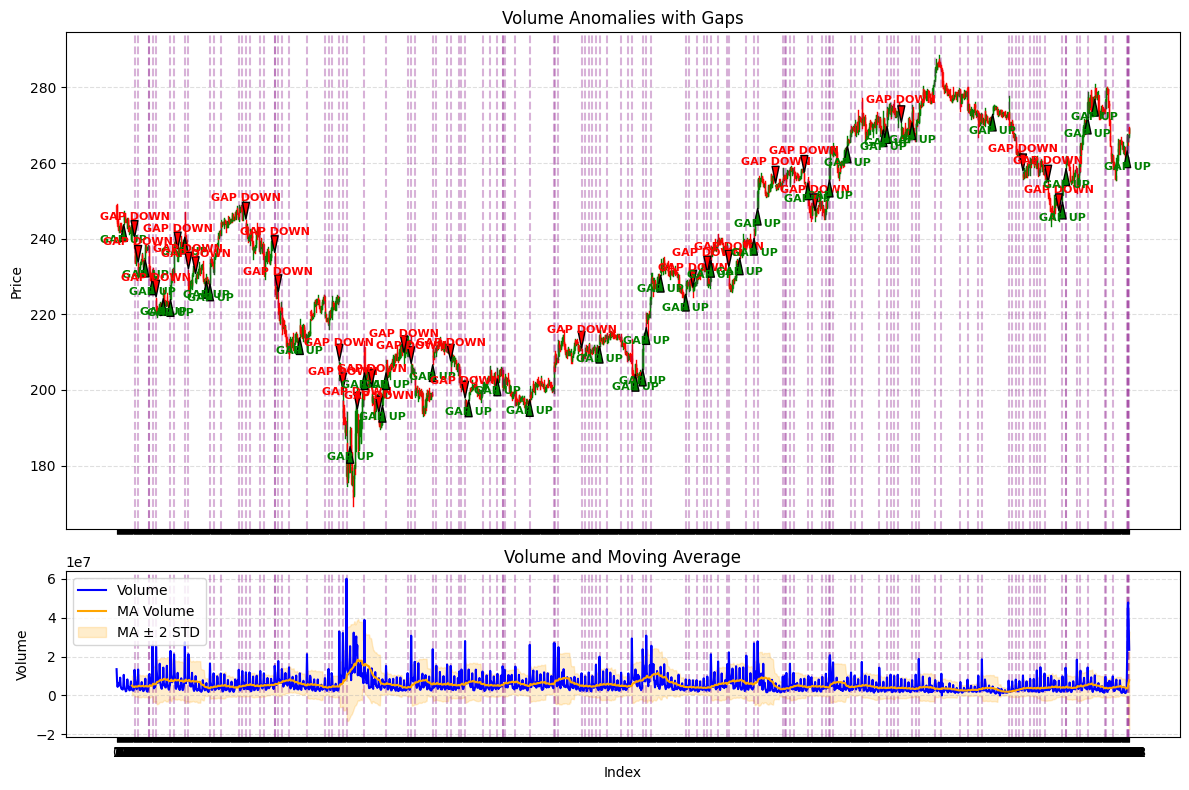

In [89]:
not_anomaly = (data_copy['Volume'] > data_copy['MA Volume'] + 2 * data_copy['STD Volume']) | (data_copy['Volume'] < data_copy['MA Volume'] - 2 * data_copy['STD Volume'])

data_copy.loc[:, 'Volume Anomaly'] = not_anomaly

# 2. Grafik Oluşturma
data_plot = data_copy.copy()
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})   
for i in range(len(data_plot)):
    # Renk belirleme: Kapanış >= Açılış ise yeşil, değilse kırmızı
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # 1. Mumun fitili (Yüksek - Düşük)
    ax[0].plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color, linewidth=1)
    
    # 2. Mumun gövdesi (Açılış - Kapanış)
    open_price = data_plot.iloc[i]['Open']
    close_price = data_plot.iloc[i]['Close']
    height = close_price - open_price
    
    # Rectangle nesnesini doğrudan ilgili aksa (ax[0]) ekliyoruz
    rect = plt.Rectangle((i - 0.3, open_price), 0.6, height, color=color, alpha=0.8)
    ax[0].add_patch(rect)

    if data_plot['Volume Anomaly'].iloc[i]:
        for a in ax:
            a.axvline(x=i, color='purple', linestyle='--', alpha=0.3, linewidth=1.5)
# 3. Gap İşaretlerini Ekleme
for i in range(len(data_plot)):
    if data_plot['Gap Up'].iloc[i]:
        ax[0].annotate('GAP UP', xy=(i, data_plot['Low'].iloc[i]), 
                    xytext=(i, data_plot['Low'].iloc[i] * 0.98), # Fiyata göre dinamik ofset
                    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='green', fontweight='bold', fontsize=8)
    
    if data_plot['Gap Down'].iloc[i]:
        ax[0].annotate('GAP DOWN', xy=(i, data_plot['High'].iloc[i]), 
                    xytext=(i, data_plot['High'].iloc[i] * 1.02),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='red', fontweight='bold', fontsize=8)
# Üst Grafik Ayarları
ax[0].set_ylabel('Price')
ax[0].set_title('Volume Anomalies with Gaps')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)
# 4. Alt Grafik (Hacim/Line Graph)
ax[1].plot(range(len(data_plot)), data_plot['Volume'], label='Volume', color='blue', linewidth=1.5)
ax[1].plot(range(len(data_plot)), data_plot['MA Volume'], label='MA Volume', color='orange', linewidth=1.5)
ax[1].fill_between(range(len(data_plot)), data_plot['MA Volume'] - 2 * data_plot['STD Volume'], data_plot['MA Volume'] + 2 * data_plot['STD Volume'], color='orange', alpha=0.2, label='MA ± 2 STD')
ax[1].set_title('Volume and Moving Average')
ax[1].set_ylabel('Volume')
ax[1].set_xlabel('Index')
ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].legend()
# 5. Estetik ve Eksen Ayarları
plt.xticks(range(len(data_plot)))
plt.tight_layout()
plt.show()

In [84]:
not_volume_anomaly = (data_copy['Short MA Volume'] <= data_copy['MA Volume']) 

gap_exists = data_copy.iloc[1:,:]['Gap Up'] | data_copy.iloc[1:,:]['Gap Down']

data_copy.loc[data_copy.index[1:], 'Common Gaps'] = not_volume_anomaly & gap_exists

In [85]:
data_copy['Common Gaps'] = (
    data_copy['Common Gaps']
    .fillna(False)
    .astype(bool)
)

In [86]:
data_copy[data_copy['Common Gaps'] == True]

,Close,High,Low,Open,Volume,Previous High,Previous Low,Gap Up,Gap Down,Common Gaps,MA Volume,STD Volume,Short MA Volume,Volume Anomaly
Datetime,,,,,,,,,,,,,,
2025-01-10 14:30:00+00:00,237.425003,240.149994,235.800003,240.024994,13137403,242.987000,241.800003,False,True,True,4.301381e+06,2.041165e+06,3576671.0,True
2025-01-15 14:30:00+00:00,237.920105,238.389999,234.429993,234.639999,8599650,233.440002,232.539993,True,False,True,4.697626e+06,2.757658e+06,3742976.4,False
2025-01-23 14:30:00+00:00,225.970001,227.029999,224.259995,224.729996,14316012,223.979996,223.059998,True,False,True,8.121117e+06,5.476508e+06,6736933.9,False
2025-01-27 14:30:00+00:00,227.292297,227.699997,224.000000,224.029999,22895716,223.044998,222.199997,True,False,True,7.364433e+06,4.799656e+06,5794532.4,True
2025-01-31 14:30:00+00:00,240.943604,247.190002,240.550003,247.039993,27334395,239.854996,237.240005,True,False,True,7.215841e+06,4.754308e+06,4863088.5,True
2025-02-05 14:30:00+00:00,229.500000,230.619705,228.300003,228.490005,9950114,233.130005,232.029999,False,True,True,7.151159e+06,5.191865e+06,4985593.4,False
2025-02-10 14:30:00+00:00,229.866196,230.585007,228.800003,229.570007,6362641,228.149994,227.259995,True,False,True,4.214819e+06,2.268806e+06,3869829.9,False
2025-02-11 14:30:00+00:00,233.339996,233.490005,228.130005,228.199997,16450165,227.880005,227.199997,True,False,True,3.732042e+06,1.845201e+06,3385228.5,True
2025-03-10 13:30:00+00:00,228.550003,236.160004,228.520004,235.479996,15210592,239.770004,237.940002,False,True,True,5.474397e+06,2.261325e+06,5372785.1,True


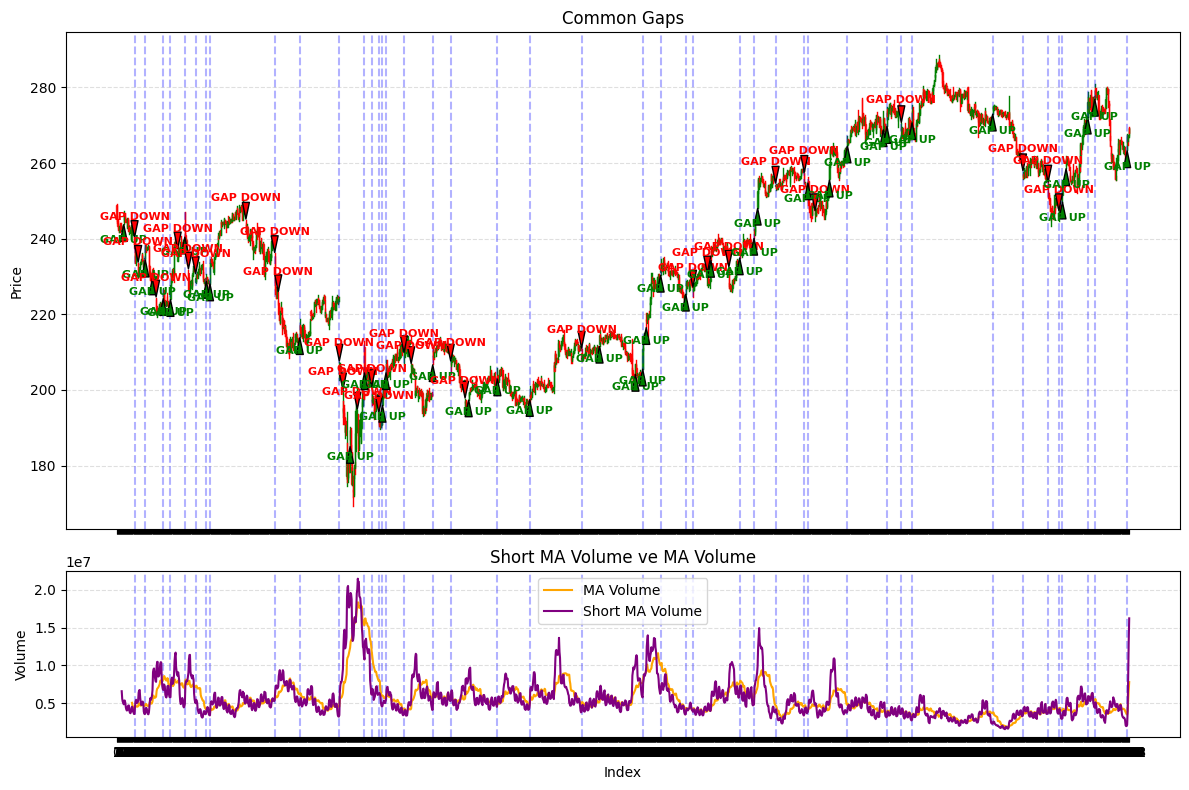

In [90]:
# 2. Grafik Oluşturma
data_plot = data_copy.copy()
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

for i in range(len(data_plot)):
    # Renk belirleme: Kapanış >= Açılış ise yeşil, değilse kırmızı
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # 1. Mumun fitili (Yüksek - Düşük)
    ax[0].plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color, linewidth=1)
    
    # 2. Mumun gövdesi (Açılış - Kapanış)
    open_price = data_plot.iloc[i]['Open']
    close_price = data_plot.iloc[i]['Close']
    height = close_price - open_price
    
    # Rectangle nesnesini doğrudan ilgili aksa (ax[0]) ekliyoruz
    rect = plt.Rectangle((i - 0.3, open_price), 0.6, height, color=color, alpha=0.8)
    ax[0].add_patch(rect)

    if data_plot['Common Gaps'].iloc[i]:
        # Her iki grafiğe de dikey çizgi ekle
        for a in ax:
            a.axvline(x=i, color='blue', linestyle='--', alpha=0.3, linewidth=1.5)

# 3. Gap İşaretlerini Ekleme
for i in range(len(data_plot)):
    if data_plot['Gap Up'].iloc[i]:
        ax[0].annotate('GAP UP', xy=(i, data_plot['Low'].iloc[i]), 
                    xytext=(i, data_plot['Low'].iloc[i] * 0.98), # Fiyata göre dinamik ofset
                    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='green', fontweight='bold', fontsize=8)
    
    if data_plot['Gap Down'].iloc[i]:
        ax[0].annotate('GAP DOWN', xy=(i, data_plot['High'].iloc[i]), 
                    xytext=(i, data_plot['High'].iloc[i] * 1.02),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                    ha='center', color='red', fontweight='bold', fontsize=8)

# Üst Grafik Ayarları
ax[0].set_ylabel('Price')
ax[0].set_title('Common Gaps')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)

# 4. Alt Grafik (Hacim/Line Graph)
# Not: ma_vlolume listesinin de ilk 30 verisini almayı unutmayın
#ax[1].plot(range(len(data_plot)), obv[-len(data_plot):], label='OBV', color='blue', linewidth=1.5)
ax[1].plot(range(len(data_plot)), data_plot['MA Volume'], label='MA Volume', color='orange', linewidth=1.5)
ax[1].plot(range(len(data_plot)), data_plot['Short MA Volume'], label='Short MA Volume', color='purple', linewidth=1.5)
ax[1].set_title('Short MA Volume ve MA Volume')
ax[1].set_ylabel('Volume')
ax[1].set_xlabel('Index')
ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].legend()

# 5. Estetik ve Eksen Ayarları
plt.xticks(range(len(data_plot)))
plt.tight_layout()
plt.show()

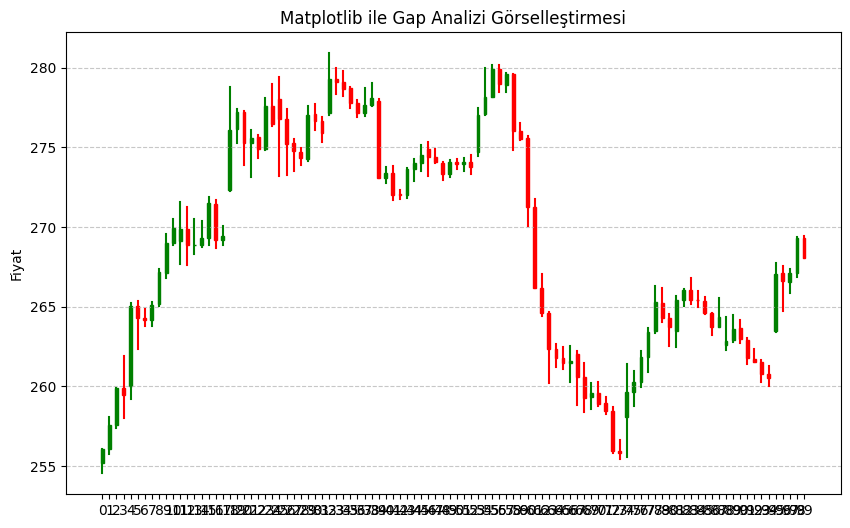

In [88]:
# 2. Grafik Oluşturma
data_plot = data_copy.iloc[-100:,:].copy()
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(data_plot)):
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # Mumun fitili (Yüksek - Düşük)
    ax.plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color)
    
    # Mumun gövdesi (Açılış - Kapanış)
    # Mum genişliğini ayarlamak için mdate veya sayısal indeks kullanılabilir
    height = data_plot.iloc[i]['Close'] - data_plot.iloc[i]['Open']
    rect = plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color, alpha=0.8)
    # Tarih ekseni yerine indeks üzerinden çizim yapıp sonra etiketleri düzelteceğiz
    ax.add_patch(plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color))

peaks = data_plot[(data_plot['Common Gaps'] == False) & (data_plot['Gap Down'] == True) ]
for idx, row in peaks.iterrows():
    plt.axhline(y=row['High'], color='black', linestyle='--', linewidth=1.5, 
                label='Gap Down Peak' if idx == peaks.index[0] else "")


    
supports = data_plot[(data_plot['Common Gaps'] == False) & (data_plot['Gap Down'] == True)]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='red', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")


peaks = data_plot[(data_plot['Common Gaps'] == False) &  (data_plot['Gap Up'] == True)]
for idx, row in peaks.iterrows():
    plt.axhline(y=row['High'], color='green', linestyle='--', linewidth=1.5, 
                label='Gap Up Peak' if idx == peaks.index[0] else "")


    
supports = data_plot[(data_plot['Common Gaps'] == False) & (data_plot['Gap Up'] == True)]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='orange', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")



# 4. Estetik Ayarlar
ax.set_xticks(range(len(data_plot)))
#ax.set_xticklabels(data_copy.index)
ax.set_title('Matplotlib ile Gap Analizi Görselleştirmesi')
ax.set_ylabel('Fiyat')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Breakaway 

In [34]:
"""data_copy = data.copy()"""

'data_copy = data.copy()'

## General Peaks

In [35]:
# Define the shorter distance between general peaks (in days)
# This controls how far apart peaks need to be to be considered separate.
peak_distance = 5

# Define the width (vertical distance) where peaks within this range will be grouped together.
# If the high prices of two peaks are closer than this value, they will be merged into a single resistance level.
peak_rank_width = 2

# Define the threshold for how many times the stock has to reject a level
# Before it becomes a resistance level
resistance_min_pivot_rank = 3

# Find general peaks in the stock's 'high' prices based on the defined distance between them.
# The peaks variable will store the indices of the high points in the 'high' price data.
peaks, _ = sp.signal.find_peaks(data_copy['High'], distance=peak_distance)

data_copy['Peaks'] = False
data_copy.iloc[peaks, data_copy.columns.get_loc('Peaks')] = True

## Strong Peaks

In [36]:
# Define the distance between strong peaks (in days).
strong_peak_distance = 30

# Define the prominence (how high the peaks are compared to their surroundings).
strong_peak_prominence = 10

# Find the strong peaks in the 'high' price data
strong_peaks, _ = sp.signal.find_peaks(
  data_copy['High'],
  distance=strong_peak_distance,
  prominence=strong_peak_prominence
)

In [37]:
data_copy['Strong Peaks'] = False
data_copy.iloc[strong_peaks, data_copy.columns.get_loc('Strong Peaks')] = True

In [38]:
data_copy.head()

,Close,High,Low,Open,Volume,Previous High,Previous Low,Gap Up,Gap Down,Common Gaps,MA Volume,STD Volume,Short MA Volume,Volume Anomaly,Peaks,Strong Peaks
Datetime,,,,,,,,,,,,,,,,
2025-01-02 14:30:00+00:00,245.739899,249.100006,244.800003,248.929993,13501229,NaN,NaN,False,False,False,NaN,NaN,NaN,False,False,False
2025-01-02 15:30:00+00:00,244.895004,245.880005,244.160095,245.630005,6830782,249.100006,244.800003,False,False,False,NaN,NaN,NaN,False,False,False
2025-01-02 16:30:00+00:00,243.428604,245.250000,243.320007,244.909897,4384552,245.880005,244.160095,False,False,False,NaN,NaN,NaN,False,False,False
2025-01-02 17:30:00+00:00,242.686203,243.410004,242.309998,243.410004,6464462,245.250000,243.320007,False,False,False,NaN,NaN,NaN,False,False,False
2025-01-02 18:30:00+00:00,242.488403,242.839996,241.820099,242.669998,5547977,243.410004,242.309998,False,False,False,NaN,NaN,NaN,False,False,False


## Support

In [39]:
peak_distance = 30

peak_prominence = 10


#troughs, _ = sp.signal.find_peaks(-data_copy['Low'], distance=peak_distance)

troughs, _ = sp.signal.find_peaks(
  -data_copy['Low'],
  distance=peak_distance,
  prominence=peak_prominence
)

data_copy['Supports'] = False
data_copy.iloc[troughs, data_copy.columns.get_loc('Supports')] = True

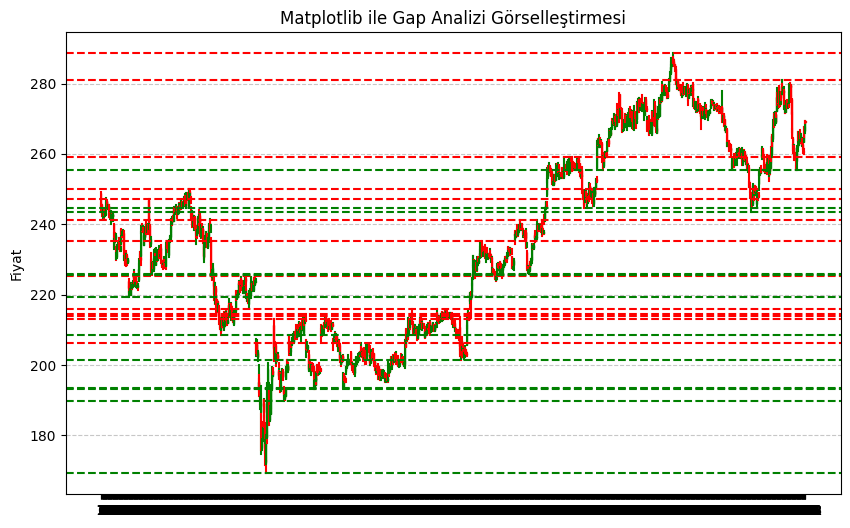

In [40]:
# 2. Grafik Oluşturma
data_plot = data_copy
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(data_plot)):
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # Mumun fitili (Yüksek - Düşük)
    ax.plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color)
    
    # Mumun gövdesi (Açılış - Kapanış)
    # Mum genişliğini ayarlamak için mdate veya sayısal indeks kullanılabilir
    height = data_plot.iloc[i]['Close'] - data_plot.iloc[i]['Open']
    rect = plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color, alpha=0.8)
    # Tarih ekseni yerine indeks üzerinden çizim yapıp sonra etiketleri düzelteceğiz
    ax.add_patch(plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color))

strong_peaks = data_plot[data_plot['Strong Peaks'] == True]
for idx, row in strong_peaks.iterrows():
    plt.axhline(y=row['High'], color='red', linestyle='--', linewidth=1.5, 
                label='Strong Peak' if idx == strong_peaks.index[0] else "")

# 2. General Peaks ama Strong Olmayanlar (Turuncu Yatay Çizgiler)
# Mantık: General == True VE Strong == False
"""weaks = data_plot[(data_plot['Peaks'] == True) & (data_plot['Strong Peaks'] == False)]
for idx, row in weaks.iterrows():
    plt.axhline(y=row['High'], color='orange', linestyle=':', linewidth=1.2, 
                label='General Peak' if idx == weaks.index[0] else "")"""
    
supports = data_plot[data_plot['Supports'] == True]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='green', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")

# 4. Estetik Ayarlar
ax.set_xticks(range(len(data_plot)))
#ax.set_xticklabels(data_copy.index)
ax.set_title('Matplotlib ile Gap Analizi Görselleştirmesi')
ax.set_ylabel('Fiyat')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

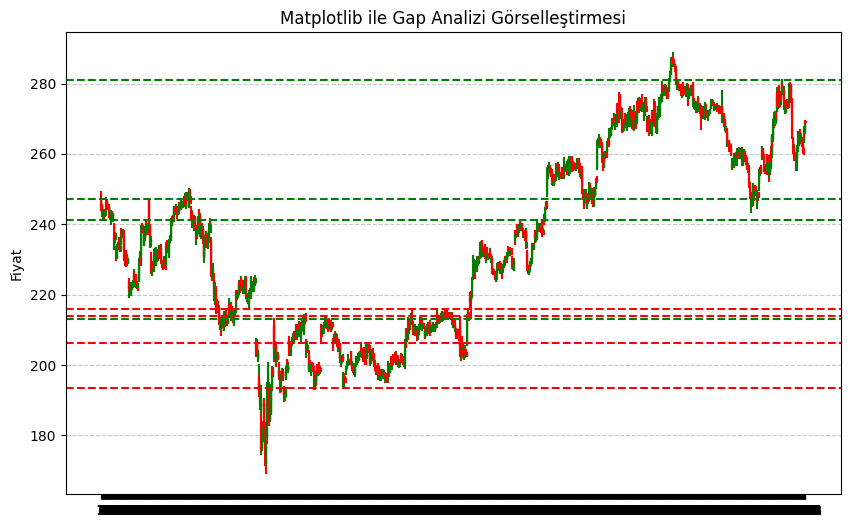

In [41]:
# 2. Grafik Oluşturma
data_plot = data_copy
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(data_plot)):
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # Mumun fitili (Yüksek - Düşük)
    ax.plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color)
    
    # Mumun gövdesi (Açılış - Kapanış)
    # Mum genişliğini ayarlamak için mdate veya sayısal indeks kullanılabilir
    height = data_plot.iloc[i]['Close'] - data_plot.iloc[i]['Open']
    rect = plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color, alpha=0.8)
    # Tarih ekseni yerine indeks üzerinden çizim yapıp sonra etiketleri düzelteceğiz
    ax.add_patch(plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color))

peaks = data_plot[(data_plot['Strong Peaks'] == True) & (data_plot['Gap Up'] == True)]
for idx, row in peaks.iterrows():
    plt.axhline(y=row['High'], color='green', linestyle='--', linewidth=1.5, 
                label='Gap Up Peak' if idx == peaks.index[0] else "")


    
supports = data_plot[(data_plot['Supports'] == True ) & (data_plot['Gap Down'] == True)]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='red', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")

peaks = data_plot[(data_plot['Strong Peaks'] == True) & (data_plot['Gap Down'] == True)]
for idx, row in peaks.iterrows():
    plt.axhline(y=row['High'], color='red', linestyle='--', linewidth=1.5, 
                label='Gap Down Peak' if idx == peaks.index[0] else "")


    
supports = data_plot[(data_plot['Supports'] == True ) & (data_plot['Gap Up'] == True)]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='green', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")


# 4. Estetik Ayarlar
ax.set_xticks(range(len(data_plot)))
#ax.set_xticklabels(data_copy.index)
ax.set_title('Matplotlib ile Gap Analizi Görselleştirmesi')
ax.set_ylabel('Fiyat')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

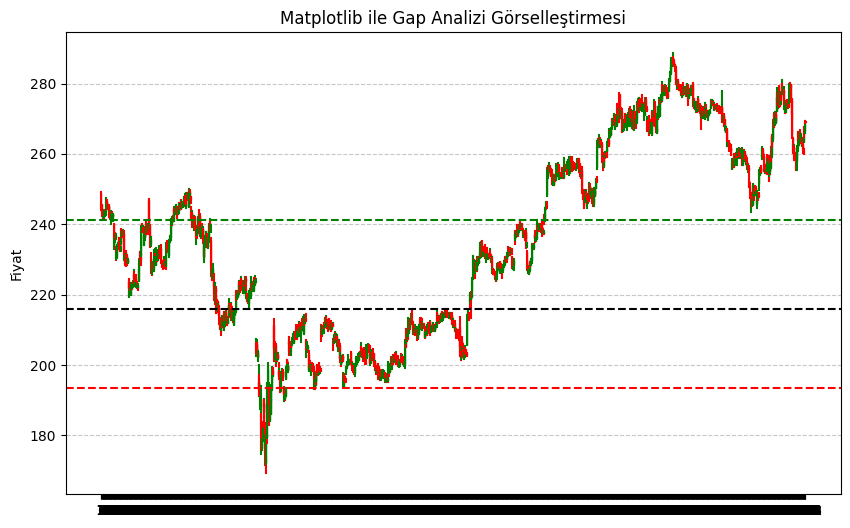

In [42]:
# 2. Grafik Oluşturma
data_plot = data_copy
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(data_plot)):
    color = 'green' if data_plot.iloc[i]['Close'] >= data_plot.iloc[i]['Open'] else 'red'
    
    # Mumun fitili (Yüksek - Düşük)
    ax.plot([i, i], [data_plot.iloc[i]['Low'], data_plot.iloc[i]['High']], color=color)
    
    # Mumun gövdesi (Açılış - Kapanış)
    # Mum genişliğini ayarlamak için mdate veya sayısal indeks kullanılabilir
    height = data_plot.iloc[i]['Close'] - data_plot.iloc[i]['Open']
    rect = plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color, alpha=0.8)
    # Tarih ekseni yerine indeks üzerinden çizim yapıp sonra etiketleri düzelteceğiz
    ax.add_patch(plt.Rectangle((i - 0.2, data_plot.iloc[i]['Open']), 0.4, height, color=color))

peaks = data_plot[(data_plot['Strong Peaks'] == True) & (data_plot['Common Gaps'] == False) & (data_plot['Gap Down'] == True) ]
for idx, row in peaks.iterrows():
    plt.axhline(y=row['High'], color='black', linestyle='--', linewidth=1.5, 
                label='Gap Down Peak' if idx == peaks.index[0] else "")


    
supports = data_plot[(data_plot['Supports'] == True ) & (data_plot['Common Gaps'] == False) & (data_plot['Gap Down'] == True)]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='red', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")


peaks = data_plot[(data_plot['Strong Peaks'] == True) & (data_plot['Common Gaps'] == False) &  (data_plot['Gap Up'] == True)]
for idx, row in peaks.iterrows():
    plt.axhline(y=row['High'], color='green', linestyle='--', linewidth=1.5, 
                label='Gap Up Peak' if idx == peaks.index[0] else "")


    
supports = data_plot[(data_plot['Supports'] == True ) & (data_plot['Common Gaps'] == False) & (data_plot['Gap Up'] == True)]
for idx, row in supports.iterrows():
    plt.axhline(y=row['Low'], color='orange', linestyle='--', linewidth=1.5, 
                label='Support' if idx == supports.index[0] else "")



# 4. Estetik Ayarlar
ax.set_xticks(range(len(data_plot)))
#ax.set_xticklabels(data_copy.index)
ax.set_title('Matplotlib ile Gap Analizi Görselleştirmesi')
ax.set_ylabel('Fiyat')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

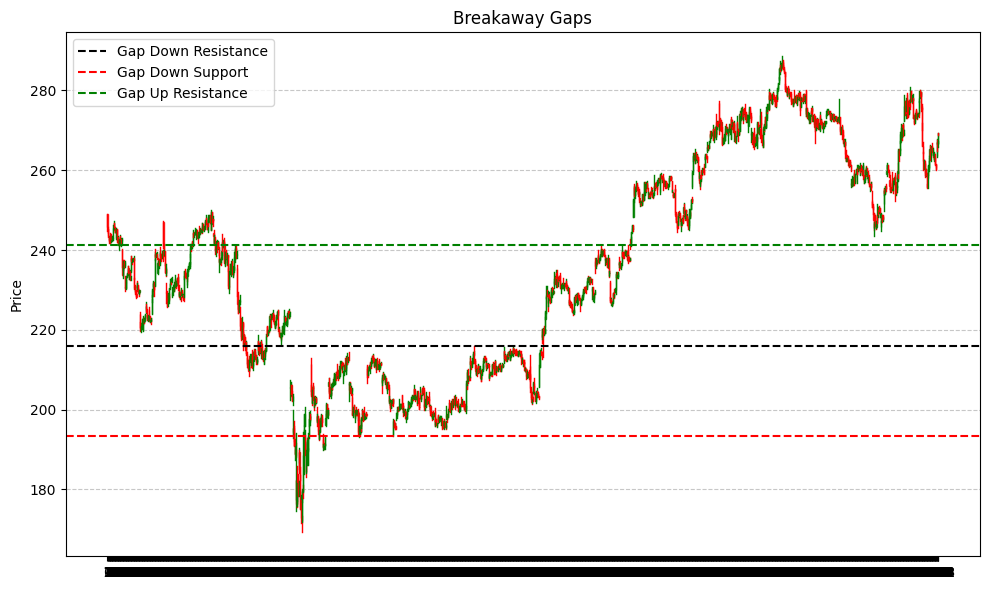

In [43]:

# =========================
# 1. Grafik Oluşturma
# =========================
data_plot = data_copy.copy()

fig, ax = plt.subplots(figsize=(10, 6))

# =========================
# 2. Mum Çizimi
# =========================
for i in range(len(data_plot)):
    open_ = data_plot.iloc[i]['Open']
    close = data_plot.iloc[i]['Close']
    high = data_plot.iloc[i]['High']
    low = data_plot.iloc[i]['Low']

    color = 'green' if close >= open_ else 'red'

    # Fitil
    ax.plot([i, i], [low, high], color=color, linewidth=1)

    # Gövde
    height = close - open_
    ax.add_patch(
        plt.Rectangle(
            (i - 0.2, open_),
            0.4,
            height if height != 0 else 0.001,
            color=color,
            alpha=0.8
        )
    )

# =========================
# 3. Gap Down – Peak & Support
# =========================
peaks_down = data_plot[
    (data_plot['Strong Peaks']) &
    (~data_plot['Common Gaps']) &
    (data_plot['Gap Down'])
]

for idx, row in peaks_down.iterrows():
    ax.axhline(
        y=row['High'],
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='Gap Down Resistance'
    )

supports_down = data_plot[
    (data_plot['Supports']) &
    (~data_plot['Common Gaps']) &
    (data_plot['Gap Down'])
]

for idx, row in supports_down.iterrows():
    ax.axhline(
        y=row['Low'],
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='Gap Down Support'
    )

# =========================
# 4. Gap Up – Peak & Support
# =========================
peaks_up = data_plot[
    (data_plot['Strong Peaks']) &
    (~data_plot['Common Gaps']) &
    (data_plot['Gap Up'])
]

for idx, row in peaks_up.iterrows():
    ax.axhline(
        y=row['High'],
        color='green',
        linestyle='--',
        linewidth=1.5,
        label='Gap Up Resistance'
    )

supports_up = data_plot[
    (data_plot['Supports']) &
    (~data_plot['Common Gaps']) &
    (data_plot['Gap Up'])
]

for idx, row in supports_up.iterrows():
    ax.axhline(
        y=row['Low'],
        color='orange',
        linestyle='--',
        linewidth=1.5,
        label='Gap Up Support'
    )


# =========================
# 5. Legend Tekilleştirme
# =========================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')

# =========================
# 6. Estetik Ayarlar
# =========================
ax.set_xticks(range(len(data_plot)))
ax.set_title('Breakaway Gaps')
ax.set_ylabel('Price')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


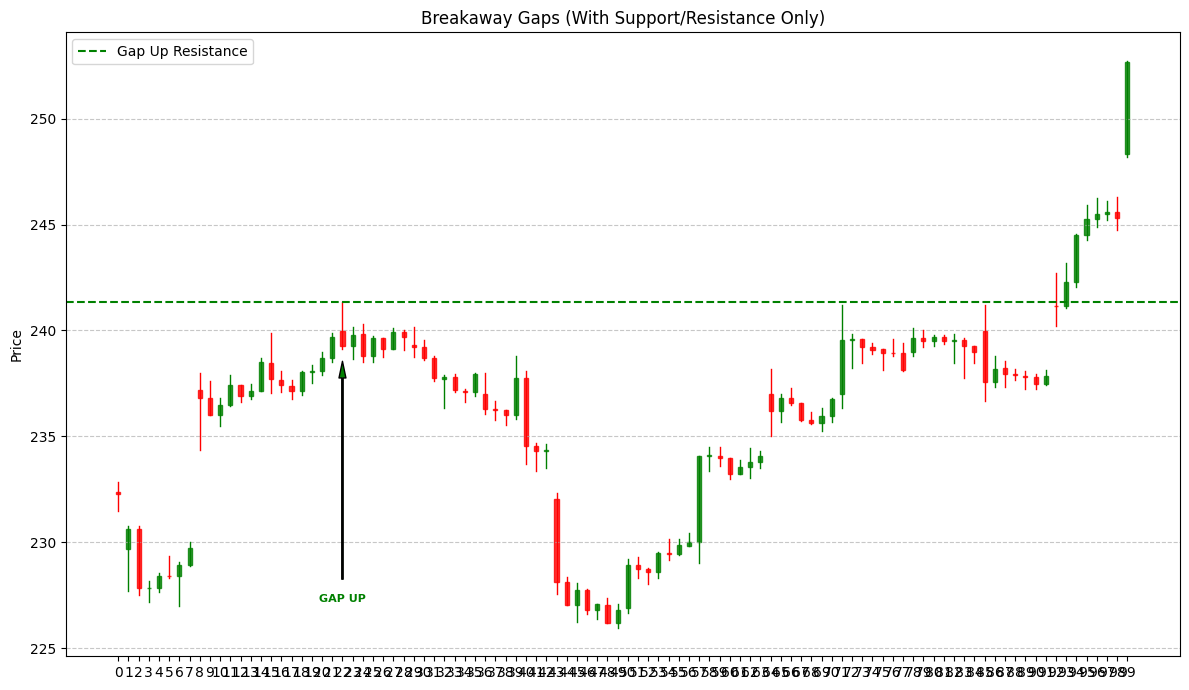

In [56]:
# =========================
# 1. Grafik Oluşturma
# =========================
data_plot = data_copy.iloc[1150:1250,:].copy()
fig, ax = plt.subplots(figsize=(12, 7))

# =========================
# 2. Mum Çizimi
# =========================
for i in range(len(data_plot)):
    open_ = data_plot.iloc[i]['Open']
    close = data_plot.iloc[i]['Close']
    high = data_plot.iloc[i]['High']
    low = data_plot.iloc[i]['Low']
    color = 'green' if close >= open_ else 'red'
    
    # Fitil
    ax.plot([i, i], [low, high], color=color, linewidth=1)
    # Gövde
    height = close - open_
    ax.add_patch(plt.Rectangle((i - 0.2, open_), 0.4, height if height != 0 else 0.001, 
                               color=color, alpha=0.8))

# =========================
# 3. Filtreleme: Sadece Çizgi Atılan Değerler
# =========================
# Gap Down olan ve Peak veya Support olanlar
gap_down_indices = data_plot[
    (data_plot['Gap Down']) & 
    (~data_plot['Common Gaps']) & 
    ((data_plot['Strong Peaks']) | (data_plot['Supports']))
].index

# Gap Up olan ve Peak veya Support olanlar
gap_up_indices = data_plot[
    (data_plot['Gap Up']) & 
    (~data_plot['Common Gaps']) & 
    ((data_plot['Strong Peaks']) | (data_plot['Supports']))
].index


# =========================
# 4. Çizgiler ve Oklar (GAP DOWN)
# =========================
for idx in gap_down_indices:
    row = data_plot.loc[idx]
    # Sayısal index'i bul (grafik x ekseni için)
    i = data_plot.index.get_loc(idx)
    
    # Direnç Çizgisi (Peak ise)
    if row['Strong Peaks']:
        ax.axhline(y=row['High'], color='black', linestyle='--', linewidth=1.5, label='Gap Down Resistance')
    
    # Destek Çizgisi (Support ise)
    if row['Supports']:
        ax.axhline(y=row['Low'], color='red', linestyle='--', linewidth=1.5, label='Gap Down Support')

    # GAP DOWN OKU
    ax.annotate('GAP DOWN', xy=(i, row['High']), 
                xytext=(i, row['High'] * 1.05),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                ha='center', color='red', fontweight='bold', fontsize=8)

# =========================
# 5. Çizgiler ve Oklar (GAP UP)
# =========================
for idx in gap_up_indices:
    row = data_plot.loc[idx]
    i = data_plot.index.get_loc(idx)
    
    # Direnç Çizgisi (Peak ise)
    if row['Strong Peaks']:
        ax.axhline(y=row['High'], color='green', linestyle='--', linewidth=1.5, label='Gap Up Resistance')
    
    # Destek Çizgisi (Support ise)
    if row['Supports']:
        ax.axhline(y=row['Low'], color='orange', linestyle='--', linewidth=1.5, label='Gap Up Support')
    

    # GAP UP OKU
    ax.annotate('GAP UP', xy=(i, row['Low']), 
                xytext=(i, row['Low'] * 0.95),
                arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                ha='center', color='green', fontweight='bold', fontsize=8)

# =========================
# 6. Legend ve Estetik
# =========================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')

ax.set_xticks(range(len(data_plot)))
ax.set_title('Breakaway Gaps (With Support/Resistance Only)')
ax.set_ylabel('Price')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

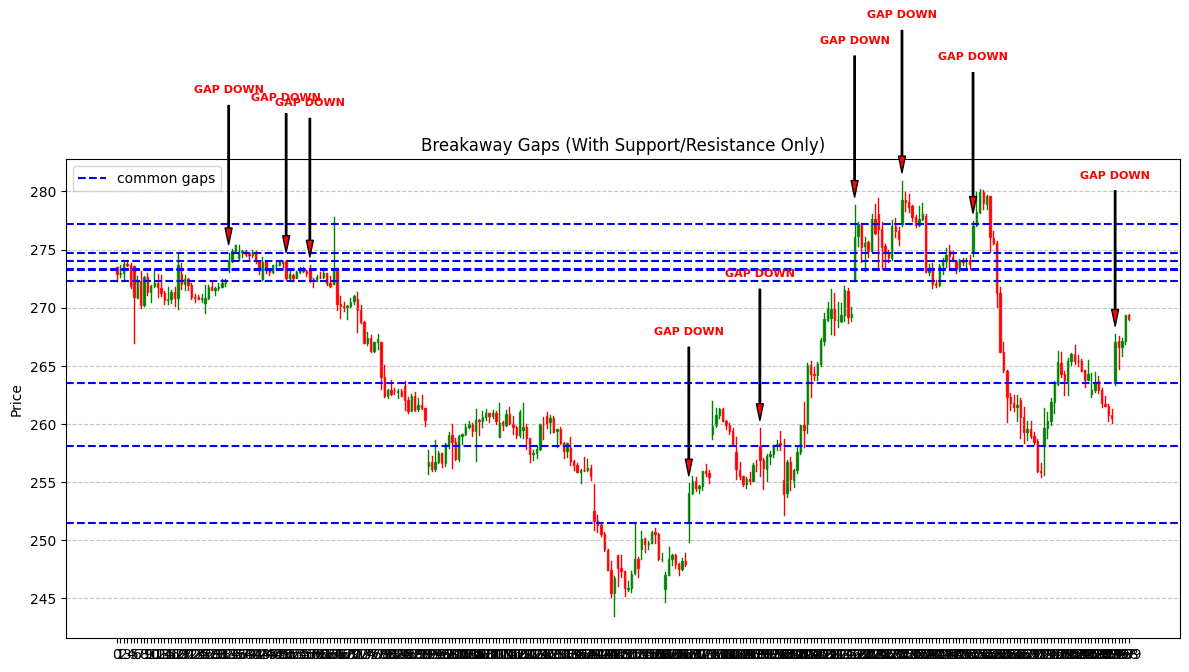

In [49]:
# =========================
# 1. Grafik Oluşturma
# =========================
data_plot = data_copy.iloc[-300:,:].copy()
fig, ax = plt.subplots(figsize=(12, 7))

# =========================
# 2. Mum Çizimi
# =========================
for i in range(len(data_plot)):
    open_ = data_plot.iloc[i]['Open']
    close = data_plot.iloc[i]['Close']
    high = data_plot.iloc[i]['High']
    low = data_plot.iloc[i]['Low']
    color = 'green' if close >= open_ else 'red'
    
    # Fitil
    ax.plot([i, i], [low, high], color=color, linewidth=1)
    # Gövde
    height = close - open_
    ax.add_patch(plt.Rectangle((i - 0.2, open_), 0.4, height if height != 0 else 0.001, 
                               color=color, alpha=0.8))

# =========================
# 3. Filtreleme: Sadece Çizgi Atılan Değerler
# =========================
# Gap Down olan ve Peak veya Support olanlar
gap_down_indices = data_plot[
    (data_plot['Gap Down']) & 
    (~data_plot['Common Gaps']) & 
    ((data_plot['Strong Peaks']) | (data_plot['Supports']))
].index

# Gap Up olan ve Peak veya Support olanlar
gap_up_indices = data_plot[
    (data_plot['Gap Up']) & 
    (~data_plot['Common Gaps']) & 
    ((data_plot['Strong Peaks']) | (data_plot['Supports']))
].index

common_gap_indices = data_plot[
    (data_plot['Gap Up']) & 
    (data_plot['Common Gaps']) & 
    (~(data_plot['Strong Peaks']) | ~(data_plot['Supports']))
].index

# =========================
# 4. Çizgiler ve Oklar (GAP DOWN)
# =========================
for idx in gap_down_indices:
    row = data_plot.loc[idx]
    # Sayısal index'i bul (grafik x ekseni için)
    i = data_plot.index.get_loc(idx)
    
    # Direnç Çizgisi (Peak ise)
    if row['Strong Peaks']:
        ax.axhline(y=row['High'], color='black', linestyle='--', linewidth=1.5, label='Gap Down Resistance')
    
    # Destek Çizgisi (Support ise)
    if row['Supports']:
        ax.axhline(y=row['Low'], color='red', linestyle='--', linewidth=1.5, label='Gap Down Support')

    # GAP DOWN OKU
    ax.annotate('GAP DOWN', xy=(i, row['High']), 
                xytext=(i, row['High'] * 1.05),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                ha='center', color='red', fontweight='bold', fontsize=8)

# =========================
# 5. Çizgiler ve Oklar (GAP UP)
# =========================
for idx in gap_up_indices:
    row = data_plot.loc[idx]
    i = data_plot.index.get_loc(idx)
    
    # Direnç Çizgisi (Peak ise)
    if row['Strong Peaks']:
        ax.axhline(y=row['High'], color='green', linestyle='--', linewidth=1.5, label='Gap Up Resistance')
    
    # Destek Çizgisi (Support ise)
    if row['Supports']:
        ax.axhline(y=row['Low'], color='orange', linestyle='--', linewidth=1.5, label='Gap Up Support')
    

    # GAP UP OKU
    ax.annotate('GAP UP', xy=(i, row['Low']), 
                xytext=(i, row['Low'] * 0.95),
                arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                ha='center', color='green', fontweight='bold', fontsize=8)


for idx in common_gap_indices:
    row = data_plot.loc[idx]
    # Sayısal index'i bul (grafik x ekseni için)
    i = data_plot.index.get_loc(idx)
    

    ax.axhline(y=row['Open'], color='Blue', linestyle='--', linewidth=1.5, label='common gaps')
    

    # GAP DOWN OKU
    ax.annotate('GAP DOWN', xy=(i, row['High']), 
                xytext=(i, row['High'] * 1.05),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                ha='center', color='red', fontweight='bold', fontsize=8)
# =========================
# 6. Legend ve Estetik
# =========================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')

ax.set_xticks(range(len(data_plot)))
ax.set_title('Breakaway Gaps (With Support/Resistance Only)')
ax.set_ylabel('Price')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()